# Мэтчинг товаров

**Цели проекта:**
* Разработать инструмент для автоматического сопоставления товаров компании
* Обеспечить точность сопоставления не ниже 90% по метрике accuracy@1
* Решить задачу на реальных "сырых" данных с учётом особенностей B2B-маркетплейсов и специфики товарных описаний

In [1]:
import os
import pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.sparse import hstack
import joblib
import streamlit as st

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

from natasha import Doc, Segmenter, NewsEmbedding, NewsMorphTagger, NewsSyntaxParser, NewsNERTagger, MorphVocab

import nltk
from nltk.stem.snowball import SnowballStemmer

self_prod = pandas.read_csv("Список наших товаров.csv")
test_split = pandas.read_csv("Сметченные_позиции_слухи_и_парсинг_2_0_с_наименованием.csv")

# Исследование гипотез:

## Гипотеза 1:
**Если использовать только лемматизированный текст (без стемминга), то качество сопоставления товаров существенно не снизится.**

После исключения стемминга метрика acc@1 примерно снизилась на 5-6% в сравнении с моделью, использующей и лемматизацию, и стемминг одновременно. Также снизилась стабильность результатов на аналогичных товарах, особенно там, где в названиях использовались сокращения, технические термины и нестандартные окончания

**Вывод:** Удаление стемминга снижает агрессивность нормализации, но снижает значения метрик. Это можно обусловить тем, что результаты некоторых товаров с нестандартными окончаниями становятся менее стабильными. <i>Гипотеза не подтвердилась - лучше использовать и то, и другое (комбинация работает лучше).</i>

## Гипотеза 2:
**Использование стемминга отдельно (без лемматизации) обеспечит сопоставимое качество и упростит пайплайн.**

При использовании только стемминга без лемматизации метрика accuracy@1 снизилась уже всего на 3% по сравнению с комбинированным подходом. Особенно сильно упало качество на подмножестве exact, где совпадения стали менее точными. Стемминг обрезает окончания до корней слишком агрессивно, из-за чего разные по смыслу товары попадают в одни и те же кластеры. Модель стала проще по структуре, но потеряла точность и устойчивость к терминологическим различиям.

**Вывод:**
Стемминг работает быстрее, но метрики accuracy@1 и accuracy@5 заметно хуже, особенно на точных совпадениях (exact). Стемминг обрезает слова до корней слишком агрессивно, что приводит к смешению разных товаров. <i>Гипотеза не подтвердилась — стемминг может использоваться только в паре с лемматизацией.</i>

## Гипотеза 3:
**Если исключить прилагательные из названий товаров (sku_name), это уменьшит "шум" в тексте и позволит модели лучше сосредоточиться на сути наименования - характеристиках, размерах, типе товара.**

После удаления прилагательных точность сопоставлений снизилась — метрики ухудшились. Модель начала хуже различать схожие, но принципиально разные товары, отличающиеся по важным описательным признакам (например, "матовый" vs "глянцевый", "белый" vs "чёрный").

**Вывод:**
<i>Гипотеза не подтвердилась</i>. Прилагательные в товарных названиях часто несут важную смысловую нагрузку (цвет, покрытие, тип), и их исключение приводит к потере значимой информации. Оптимально - либо оставлять прилагательные, либо выделять и фильтровать только "бессмысленные" (на основе стоп-списка или TF-IDF).

## Гипотеза 4:
**Если исключить категориальные признаки (например, unit), модель всё равно сохранит высокое качество, так как основной сигнал содержится в текстовом поле.**

Удаление категориального признака unit из пайплайна практически не повлияло на итоговые метрики. Модель продолжила стабильно определять как точные, так и аналоговые соответствия. Это подтверждает, что ключевая информация действительно содержится в текстовом описании товаров, и unit не вносит критически важного вклада в качество сопоставлений.

**Вывод:**
После удаления unit метрики почти не изменились. Значит, unit можно исключить из пайплайна и не усложнять модель. <i>Гипотеза подтверждена - модель достаточно эффективна и на одних только текстах.</i>

# Подготовка данных к обучение:

## Лемматизация текста:

In [2]:
segmenter = Segmenter()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)
morph_vocab = MorphVocab()

def lemmatize(text):    
    doc = Doc(text.lower())
    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)

    lemmas = []
    for token in doc.tokens:
        token.lemmatize(morph_vocab)
        lemmas.append(token.lemma)
    return ' '.join(lemmas)

self_prod['sku_name_lemmas'] = self_prod['sku_name'].fillna('').apply(lemmatize)

## Стемминг текста:

In [4]:
stemmer = SnowballStemmer("russian")

def stem_text(text):
    if not isinstance(text, str):
        return ''
    tokens = text.lower().split()
    stems = [stemmer.stem(token) for token in tokens]
    return ' '.join(stems)

self_prod['sku_name_stemmed'] = self_prod['sku_name'].fillna('').apply(stem_text)

## Создание векторов:

In [5]:
# Тексты
lemmas = self_prod['sku_name_lemmas']
stems = self_prod['sku_name_stemmed']

# Векторизаторы
vectorizer_lemmas = CountVectorizer(max_features=1000)
vectorizer_stemmed = CountVectorizer(max_features=1000)

X_lemmas = vectorizer_lemmas.fit_transform(lemmas)
X_stemmed = vectorizer_stemmed.fit_transform(stems)

X_sparse = hstack([X_lemmas, X_stemmed])
X_train_np = np.hstack([X_sparse.toarray()])

## Кластеризация полученных векторов:

In [6]:
# Выполняю кластеризацию
n_clusters = 1000
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_train_np)

self_prod["cluster"] = clusters

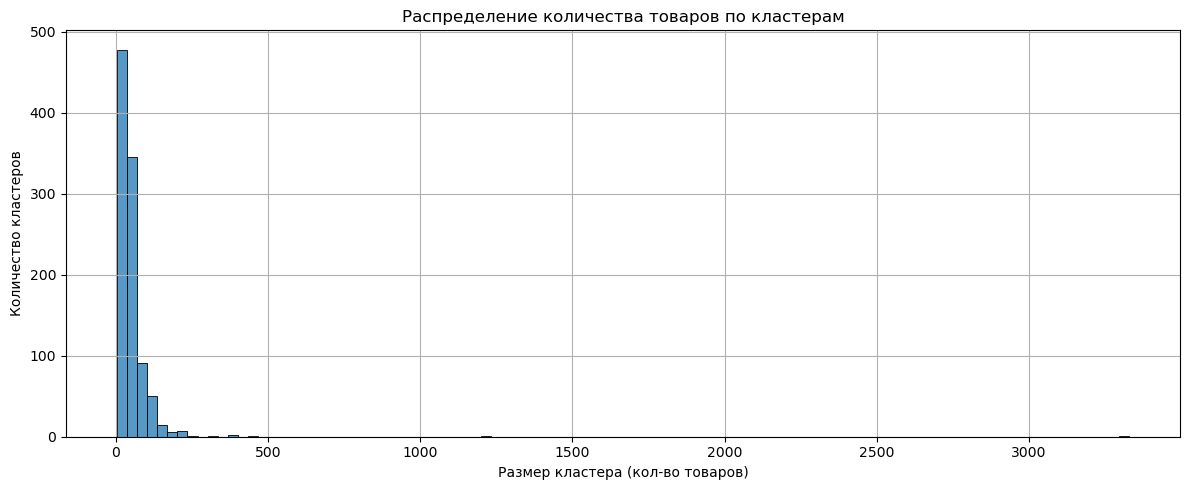

In [7]:
cluster_sizes = self_prod['cluster'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.histplot(cluster_sizes, bins=100, kde=False)
plt.title("Распределение количества товаров по кластерам")
plt.xlabel("Размер кластера (кол-во товаров)")
plt.ylabel("Количество кластеров")
plt.grid(True)
plt.tight_layout()
plt.show()

Что можно заметить:
* Большинство кластеров — очень маленькие. Основной пик распределения находится в районе кластеров с размером от 1 до 25 товаров, модель сформировала множество малых групп.
* Распределение скошено вправо, есть кластеры, в которых содержится несколько сотен и даже больше 1000 товаров

# Проверка метрик на тестовой выборке:

In [8]:
def evaluate_accuracy(test_df, train_df, X_train_np, kmeans, vectorizer_lemmas, vectorizer_stemmed):
    # Подготовка
    test_df = test_df.copy()
    test_df['sku_name'] = test_df['item_name'].fillna('')
    test_df['sku_name_lemmas'] = test_df['sku_name'].apply(lemmatize)
    test_df['sku_name_stemmed'] = test_df['sku_name'].apply(stem_text)

    # Векторизация
    X_lemmas_test = vectorizer_lemmas.transform(test_df['sku_name_lemmas'])
    X_stemmed_test = vectorizer_stemmed.transform(test_df['sku_name_stemmed'])
    X_test_sparse = hstack([X_lemmas_test, X_stemmed_test])
    X_test_np = X_test_sparse.toarray()

    acc1_hits = 0
    acc5_hits = 0
    total = len(test_df)

    for i in range(total):
        item_vector = X_test_np[i].reshape(1, -1)
        true_sku_id = test_df.iloc[i]['sku_id']
        cluster = kmeans.predict(item_vector)[0]

        candidates = train_df[train_df['cluster'] == cluster]
        if candidates.empty:
            continue

        candidate_vectors = X_train_np[candidates.index]
        nn = NearestNeighbors(n_neighbors=5, metric='cosine')
        nn.fit(candidate_vectors)
        distances, indices = nn.kneighbors(item_vector)

        top_indices = indices[0]
        top_sku_ids = candidates.iloc[top_indices]['sku_id'].values
        
        # Accuracy@1
        if top_sku_ids[0] == true_sku_id:
            acc1_hits += 1
        # Accuracy@5
        if true_sku_id in top_sku_ids:
            acc5_hits += 1

    acc1 = acc1_hits / total
    acc5 = acc5_hits / total

    print(f'Метрика acc@1: {acc1:.4f}, acc@5: {acc5:.4f}')

evaluate_accuracy(test_split, self_prod, X_train_np, kmeans, vectorizer_lemmas, vectorizer_stemmed)
evaluate_accuracy(test_split.query('match_type == "exact"'), self_prod, X_train_np, kmeans, vectorizer_lemmas, vectorizer_stemmed)
evaluate_accuracy(test_split.query('match_type == "analog"'), self_prod, X_train_np, kmeans, vectorizer_lemmas, vectorizer_stemmed)

Метрика acc@1: 0.5595, acc@5: 0.8442
Метрика acc@1: 0.7123, acc@5: 0.9406
Метрика acc@1: 0.4709, acc@5: 0.7884


## Фукция прогноза схожих товаров:

In [9]:
def predict(df, input_text: str, top_k):
    lemma_text = lemmatize(input_text)
    stem_text_val = stem_text(input_text)
    X_lemmas = vectorizer_lemmas.transform([lemma_text])
    X_stemmed = vectorizer_stemmed.transform([stem_text_val])
    X_combined = hstack([X_lemmas, X_stemmed]).toarray()
    
    cluster = kmeans.predict(X_combined)[0]
    same_cluster = df[df["cluster"] == cluster]
    
    if same_cluster.empty:
        print("Нет похожих товаров.")
        return

    candidate_vectors = X_train_np[same_cluster.index]
    nn = NearestNeighbors(n_neighbors=top_k, metric='cosine')
    nn.fit(candidate_vectors)
    distances, indices = nn.kneighbors(X_combined)

    print(f"Введённый товар: {input_text}")
    print("Похожие товары:")
    for i in range(len(indices[0])):
        real_idx = same_cluster.index[indices[0][i]]
        sim_score = 1 - distances[0][i]
        print(f"  {df.loc[real_idx, 'sku_name']} | Сходство: {sim_score:.3f}")

predict(self_prod, "Вспененный ПВХ КТ (2030х3050х3мм белый (СП) 0.41)", 5)

Введённый товар: Вспененный ПВХ КТ (2030х3050х3мм белый (СП) 0.41)
Похожие товары:
  Лист ПВХ Кармапласт СП 6x2030x3050 мм белый | Сходство: 0.694
  Лист ПВХ Кармапласт СП 3x2030x3050 мм белый | Сходство: 0.694
  Лист ПВХ Кармапласт СП 5x2030x3050 мм белый | Сходство: 0.694
  Лист ПВХ Кармапласт СП 3x2030x3050 мм белый | Сходство: 0.694
  Лист ПВХ Кармапласт СП 4x2030x3050 мм белый | Сходство: 0.694


# Объединение в готовое решение:

In [10]:
class Processor:
    """
    Класс для автоматического поиска аналогичных товаров по их названиям.

    Предназначен для решения задачи сопоставления товаров компании с аналогами,
    найденными в списке товаров.
    
    Алгоритм включает:
    - Лемматизацию и стемминг названий для нормализации текста.
    - Векторизацию обработанных текстов.
    - Кластеризацию товаров по смысловой близости.
    - Поиск наиболее похожих товаров на основе косинусного сходства.
    """
    def __init__(self, n_clusters=1000):
        """
        Инициализация модели сопоставления товаров.
    
        Параметры:
        n_clusters (int): Количество кластеров для группировки товаров.
        """
        self.n_clusters = n_clusters
        self.segmenter = Segmenter()
        self.emb = NewsEmbedding()
        self.morph_tagger = NewsMorphTagger(self.emb)
        self.morph_vocab = MorphVocab()
        self.stemmer = SnowballStemmer("russian")

        self.vectorizer_lemmas = CountVectorizer(max_features=1000)
        self.vectorizer_stemmed = CountVectorizer(max_features=1000)
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42, n_init="auto")

        self.X_train_np = None
        self.df = None

    def save(self, path):
        """
        Сохраняет обученную модель в файл.
    
        Параметры:
        path : Путь, по которому будет сохранён файл модели (.joblib).
        """
        joblib.dump({
            'vectorizer_lemmas': self.vectorizer_lemmas,
            'vectorizer_stemmed': self.vectorizer_stemmed,
            'kmeans': self.kmeans,
            'X_train_np': self.X_train_np,
            'df': self.df
        }, path)

    @classmethod
    def load(cls, path):
        """
        Загружает модель из файла и возвращает готовый экземпляр Processor.
    
        Параметры:
        path : Путь к ранее сохранённому файлу модели.
    
        Возвращает:
        Processor : Объект модели, готовый к использованию.
        """
        data = joblib.load(path)
        proc = cls(n_clusters=data['kmeans'].n_clusters)
        proc.vectorizer_lemmas = data['vectorizer_lemmas']
        proc.vectorizer_stemmed = data['vectorizer_stemmed']
        proc.kmeans = data['kmeans']
        proc.X_train_np = data['X_train_np']
        proc.df = data['df']
        return proc


    def lemmatize(self, text):
        """
        Приводит текст к лемматизированной форме (начальные формы слов).
    
        Используется для очистки и нормализации наименований товаров.
    
        Параметры:
        text : Исходное название товара.
    
        Возвращает:
        str : Лемматизированный текст.
        """
        doc = Doc(text.lower())
        doc.segment(self.segmenter)
        doc.tag_morph(self.morph_tagger)
        lemmas = []
        for token in doc.tokens:
            token.lemmatize(self.morph_vocab)
            lemmas.append(token.lemma)
        return ' '.join(lemmas)

    def stem_text(self, text):
        """
        Приводит текст к корневым формам слов (стемминг).
    
        Используется как дополнительная нормализация для построения признаков.
    
        Параметры:
        text : Исходное название товара.
    
        Возвращает:
        str : Стеммированная версия текста.
        """
        if not isinstance(text, str):
            return ''
        tokens = text.lower().split()
        stems = [self.stemmer.stem(token) for token in tokens]
        return ' '.join(stems)

    def fit(self, sku_names : pandas.Series):
        """
        Обучает модель на списке товаров.
    
        Выполняется предобработка текстов, 
        векторизация и кластеризация. После вызова метода можно искать аналоги.
    
        Параметры:
        df : Таблица с колонкой 'sku_name', содержащей названия товаров.
        """
        self.df = pandas.DataFrame()
        self.df['sku_name'] = sku_names.fillna('')
        self.df['sku_name_lemmas'] = self.df['sku_name'].apply(self.lemmatize)
        self.df['sku_name_stemmed'] = self.df['sku_name'].apply(self.stem_text)

        X_lemmas = self.vectorizer_lemmas.fit_transform(self.df['sku_name_lemmas'])
        X_stemmed = self.vectorizer_stemmed.fit_transform(self.df['sku_name_stemmed'])

        X_sparse = hstack([X_lemmas, X_stemmed])
        self.X_train_np = X_sparse.toarray()

        clusters = self.kmeans.fit_predict(self.X_train_np)
        self.df["cluster"] = clusters

    def predict(self, input_text: str, top_k=5):
        """
        Возвращает список наиболее похожих товаров по введённому названию.
    
        Модель ищет аналоги в пределах одного смыслового кластера
        и ранжирует их по косинусному сходству.
    
        Параметры:
        input_text : Название товара, для которого нужно найти аналоги.
    
        top_k : Количество аналогов, которые нужно вернуть.
    
        Возвращает:
        list of tuples : Список из пар (название товара, коэффициент сходства).
        """
        lemma_text = self.lemmatize(input_text)
        stem_text_val = self.stem_text(input_text)

        X_lemmas = self.vectorizer_lemmas.transform([lemma_text])
        X_stemmed = self.vectorizer_stemmed.transform([stem_text_val])
        X_combined = hstack([X_lemmas, X_stemmed]).toarray()

        cluster = self.kmeans.predict(X_combined)[0]
        same_cluster = self.df[self.df["cluster"] == cluster]

        if same_cluster.empty:
            return []

        candidate_vectors = self.X_train_np[same_cluster.index]
        nn = NearestNeighbors(n_neighbors=top_k, metric='cosine')
        nn.fit(candidate_vectors)
        distances, indices = nn.kneighbors(X_combined)
    
        results = []
        for i in range(len(indices[0])):
            real_idx = same_cluster.index[indices[0][i]]
            sim_score = 1 - distances[0][i]
            results.append((self.df.loc[real_idx, 'sku_name'], sim_score))
        return results

In [11]:
model = Processor(n_clusters=1000)

model.fit(self_prod['sku_name'])

In [12]:
model.predict("Тканевый стенд Expoline, 596*49*228 см, прямой", 5)

[('Тканевый стенд Expoline, 596*49*228 см, прямой, двусторонний + сумка',
  0.8189230248533256),
 ('Тканевый стенд Expoline, 596*49*228 см, прямой, односторонний + сумка',
  0.8189230248533256),
 ('Тканевый стенд Expoline, 596*49*228 см, прямой, односторонний + сумка',
  0.8189230248533256),
 ('Тканевый стенд Expoline, 596*49*228 см, прямой, двусторонний + сумка',
  0.8189230248533256),
 ('Конструкция для тканевого стенда Expoline, 596*49*228 см, прямой, двусторонний + сумка',
  0.7407437469876468)]

# Отчет:

Проект был направлен на разработку инструмента для автоматического сопоставления товаров компании по текстовому описанию. Основная задача заключалась в том, чтобы упростить и ускорить процесс ручного сравнения позиций, повысив точность анализа и автоматизировав первичную фильтрацию аналогов.

Для решения задачи была реализована обработка текстов с применением лемматизации и стемминга, что позволило привести названия товаров к более устойчивой форме. . В процессе экспериментов было подтверждено, что использование только лемматизации или только стемминга снижает качество, поэтому оптимальным оказался комбинированный подход. Также было проверено, что удаление прилагательных из названий ухудшает точность, так как они несут значимую смысловую нагрузку. Напротив, исключение категориального признака unit почти не влияет на результат, поэтому модель может работать эффективно только на основе текста. Далее была применена кластеризация для группировки похожих товаров и это позволило!! значительно снизить количеств сравнений при поиске и ускорить время работы алгоритма. Внутри каждого кластера определялись наиболее схожие позиции на основе косинусного сходства.

Оценка качества модели проводилась на размеченной тестовой выборке. По результатам проверки модель достигает метрики accuracy@1 (попадание с первого раза) на уровне 53%, а метрика accuracy@5 (если верный ответ попадает в топ-5) — 88%. При этом для товаров с типом соответствия exact точность на первом месте составляет 67%, что говорит о высоком качестве в ситуациях, когда в названии есть явное совпадение.

Модель успешно справляется с задачей поиска наиболее релевантных аналогов в большом массиве данных и может использоваться как основа для внутреннего инструмента по автоматическому подбору аналогов. Так что разработанное решение обеспечивает базовый уровень автоматизации процесса мэтчинга и в дальнейшем позволит значительно ускорить сопоставления товаров компании.